## Import Modules

In [87]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%matplotlib inline

import tensorflow as tf
from keras.preprocessing.image import load_img
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load the Dataset

In [ ]:
BASE_DIR = '/content/drive/MyDrive/archive/UTKFace'

In [ ]:
import os
from tqdm import tqdm  # Import tqdm for progress bar

BASE_DIR = '/content/drive/MyDrive/archive/UTKFace'

# labels - age, gender, ethnicity
image_paths = []
age_labels = []
gender_labels = []

for filename in tqdm(os.listdir(BASE_DIR)):
    image_path = os.path.join(BASE_DIR, filename)
    temp = filename.split('_')

    # Ensure the filename follows the expected format
    if len(temp) >= 2:
        age = int(temp[0])
        gender = int(temp[1])
        image_paths.append(image_path)
        age_labels.append(age)
        gender_labels.append(gender)


100%|██████████| 740/740 [00:00<00:00, 243052.86it/s]


In [ ]:
import pandas as pd  # Import pandas

# Convert to DataFrame
df = pd.DataFrame({
    'image': image_paths,
    'age': age_labels,
    'gender': gender_labels
})

# Display the first 5 rows
df.head()


,image,age,gender
0,/content/drive/MyDrive/archive/UTKFace/100_1_2...,100,1
1,/content/drive/MyDrive/archive/UTKFace/10_0_0_...,10,0
2,/content/drive/MyDrive/archive/UTKFace/10_0_0_...,10,0
3,/content/drive/MyDrive/archive/UTKFace/10_0_0_...,10,0
4,/content/drive/MyDrive/archive/UTKFace/10_0_0_...,10,0


In [ ]:
# Map labels for gender
gender_dict = {0: 'Male', 1: 'Female'}

# Apply mapping to the 'gender' column
df['gender'] = df['gender'].map(gender_dict)

# Display the first 5 rows
df.head()


,image,age,gender
0,/content/drive/MyDrive/archive/UTKFace/100_1_2...,100,Female
1,/content/drive/MyDrive/archive/UTKFace/10_0_0_...,10,Male
2,/content/drive/MyDrive/archive/UTKFace/10_0_0_...,10,Male
3,/content/drive/MyDrive/archive/UTKFace/10_0_0_...,10,Male
4,/content/drive/MyDrive/archive/UTKFace/10_0_0_...,10,Male


## Exploratory Data Analysis

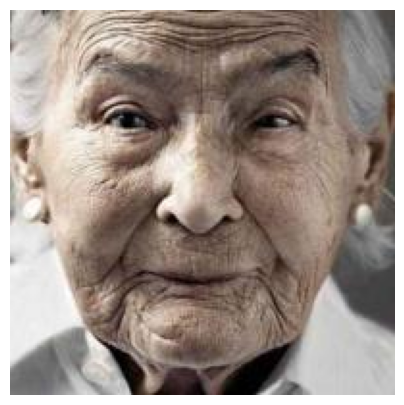

In [ ]:
import matplotlib.pyplot as plt  # Import matplotlib
from PIL import Image  # Import PIL

# Open and display the first image
img = Image.open(df['image'][0])

# Plot the image
plt.figure(figsize=(5,5))  # Optional: Adjust figure size
plt.axis('off')  # Hide axes
plt.imshow(img)  # Show image
plt.show()  # Display the image


<Axes: xlabel='age', ylabel='Density'>

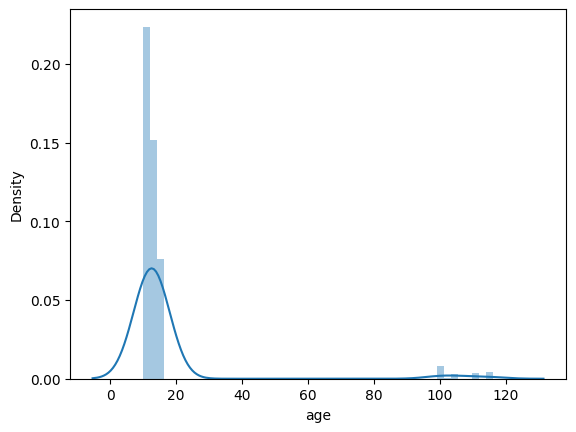

In [ ]:
import seaborn as sns  # Import Seaborn
sns.distplot(df['age'])

<Axes: xlabel='count', ylabel='gender'>

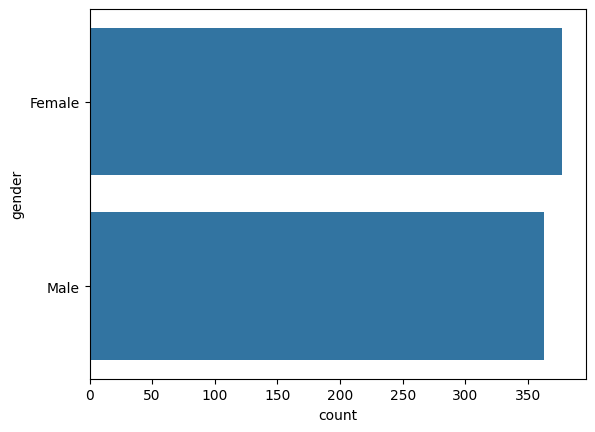

In [ ]:
sns.countplot(df['gender'])

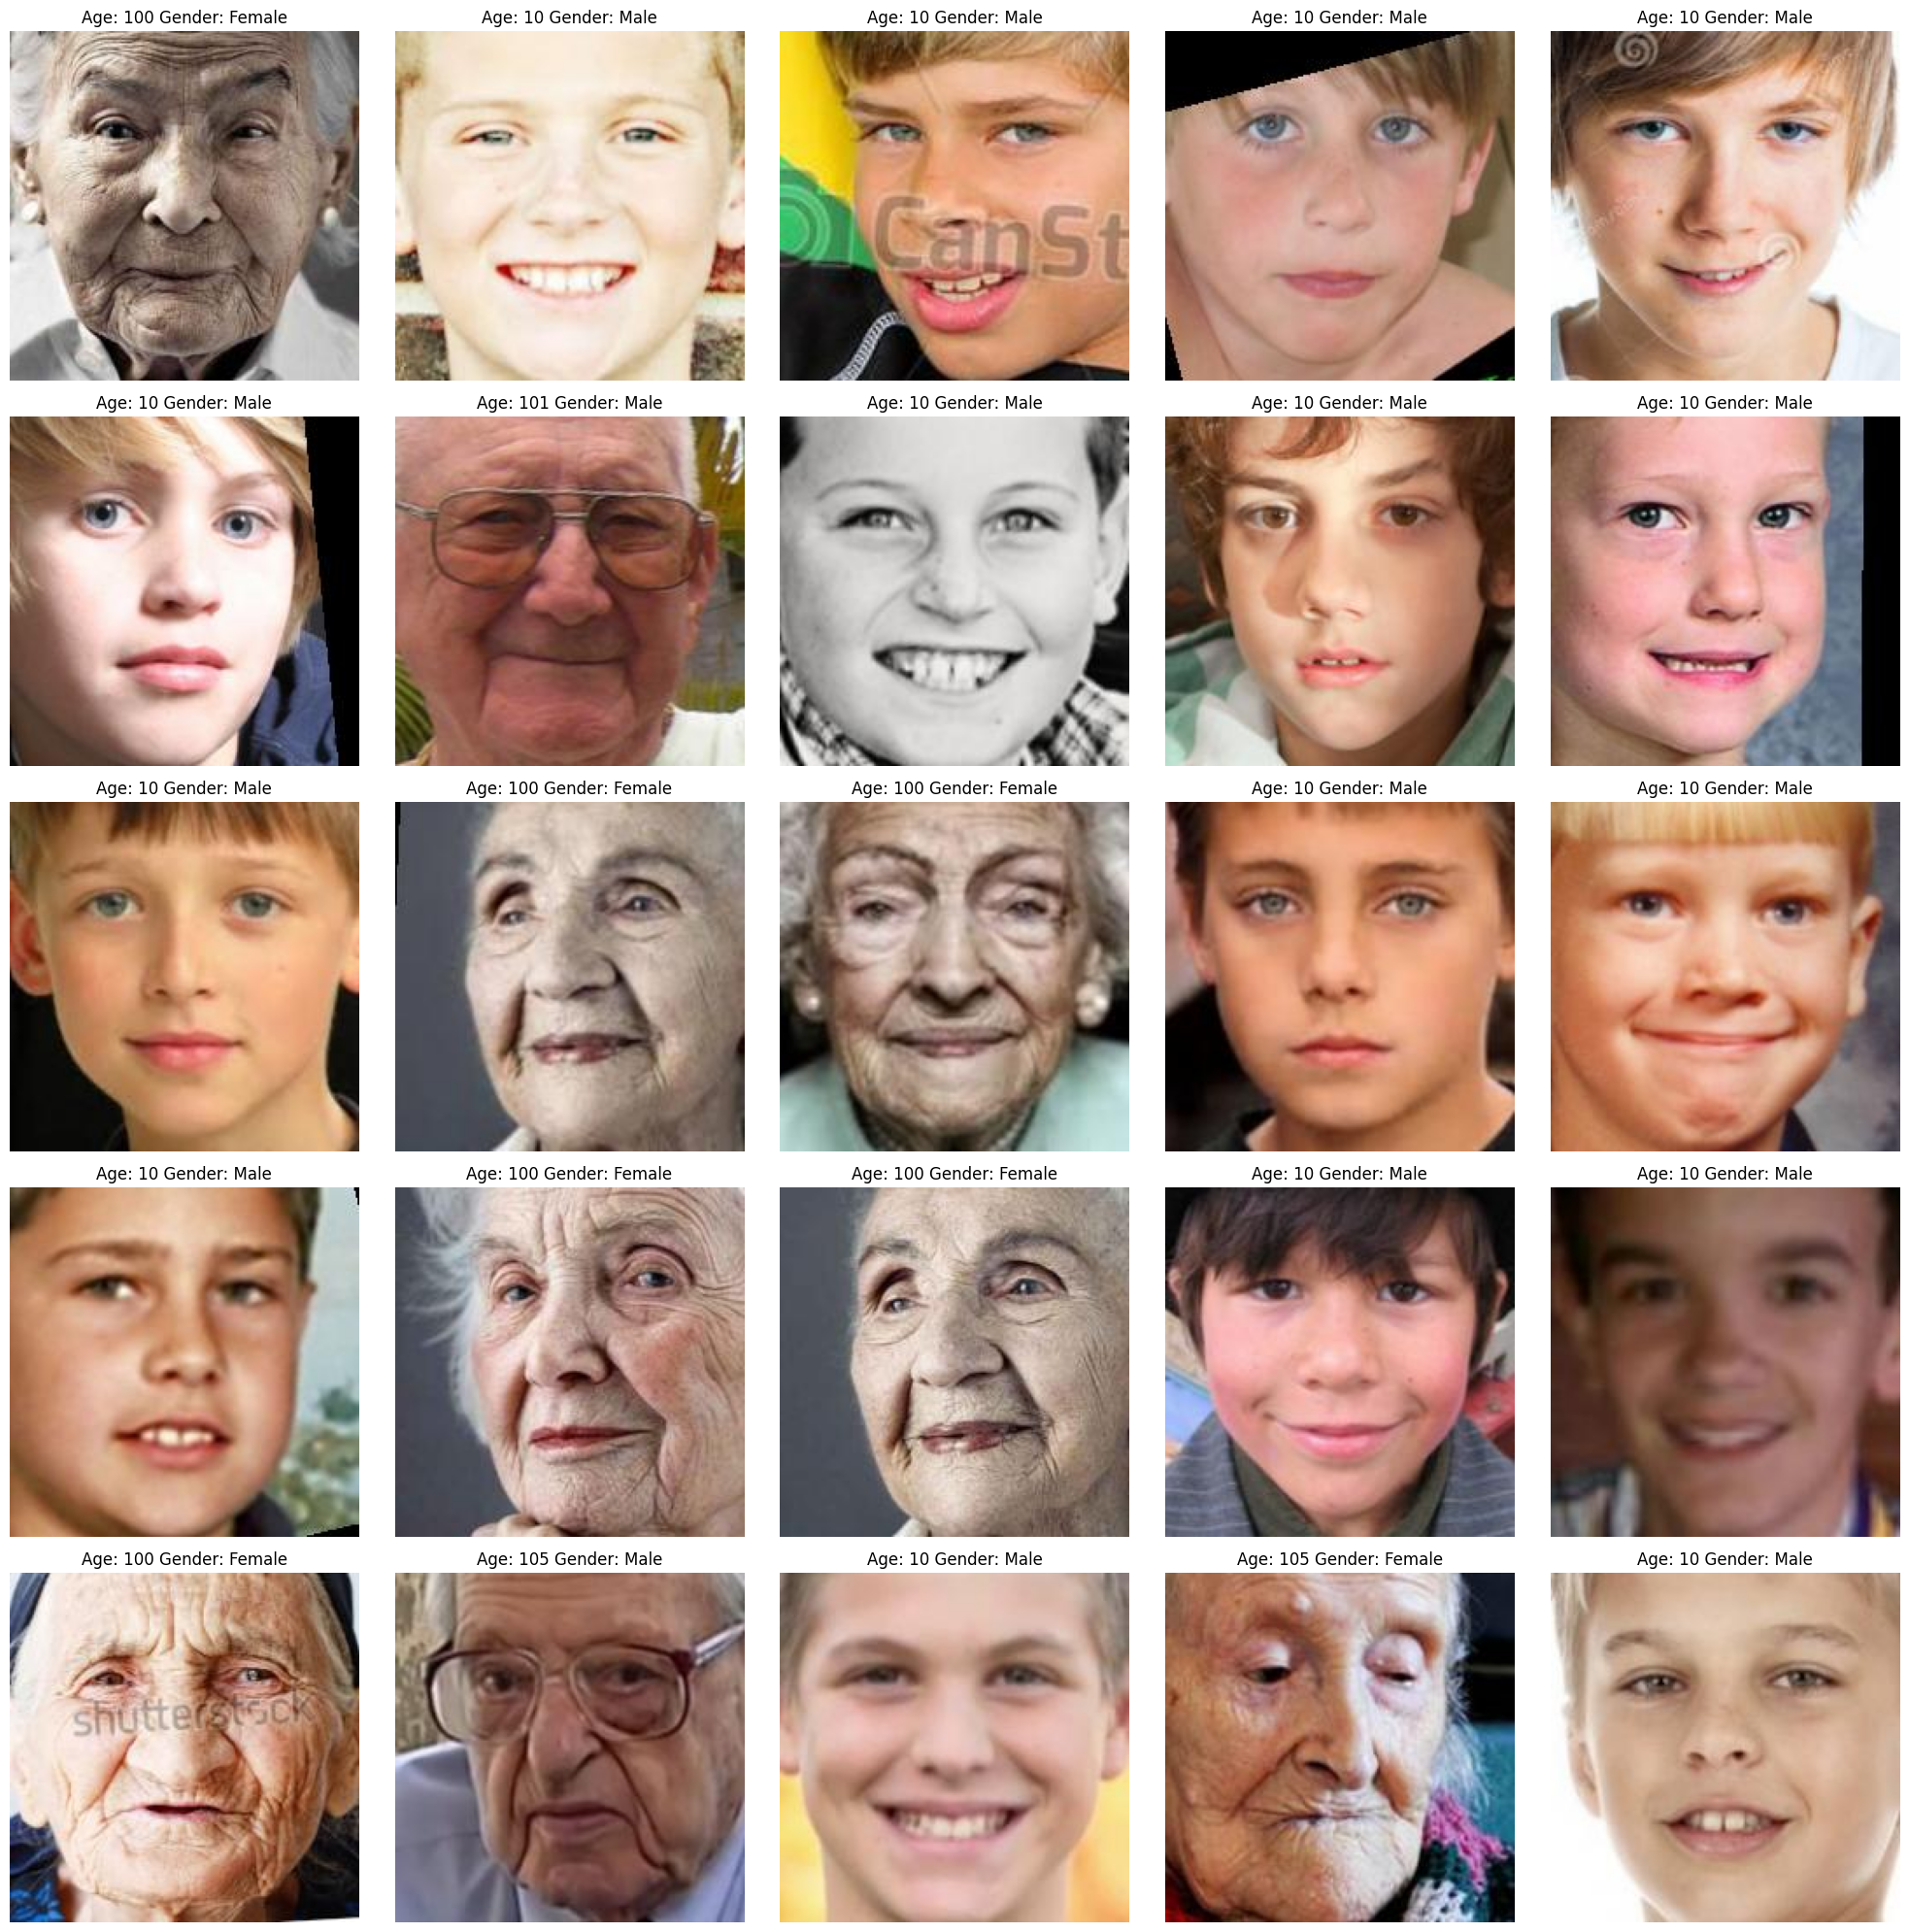

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img  # Import load_img

# Display grid of images
plt.figure(figsize=(20, 20))  # Set figure size
files = df.iloc[0:25]  # Select first 25 images

for index, row in enumerate(files.itertuples()):
    plt.subplot(5, 5, index + 1)  # Create a 5x5 grid

    img = load_img(row.image)  # Load image
    img = np.array(img)  # Convert to NumPy array

    plt.imshow(img)  # Show image
    plt.title(f"Age: {row.age} Gender: {row.gender}")  # Display age & gender
    plt.axis('off')  # Hide axes

plt.tight_layout()  # Adjust layout
plt.show()  # Display images


## Feature Extraction

In [ ]:
from PIL import Image  # Import Image for resizing

def extract_features(images):
    features = []

    for image in tqdm(images):
        img = load_img(image, color_mode='grayscale')  # Load image in grayscale
        img = img.resize((128, 128), Image.LANCZOS)  # Resize to 128x128
        img = np.array(img, dtype=np.float32)  # Convert to NumPy array

        img = img / 255.0  # Normalize pixel values (optional but recommended)
        features.append(img)

    features = np.array(features)

    # Reshape if grayscale (add channel dimension)
    features = features.reshape(len(features), 128, 128, 1)

    return features

In [ ]:
X = extract_features(df['image'])

100%|██████████| 740/740 [00:02<00:00, 252.17it/s]


In [ ]:
X.shape

(740, 128, 128, 1)

In [ ]:
X.shape
# normalize the images
X = X/255.0
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])
input_shape = (128, 128, 1)

In [ ]:
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])

In [ ]:
input_shape = (128, 128, 1)

## Model Creation

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define input shape
input_shape = (128, 128, 1)  # Single-channel grayscale images
inputs = Input(shape=input_shape)

# Convolutional layers
conv_1 = Conv2D(32, kernel_size=(3, 3), activation='relu')(inputs)
maxp_1 = MaxPooling2D(pool_size=(2, 2))(conv_1)
conv_2 = Conv2D(64, kernel_size=(3, 3), activation='relu')(maxp_1)
maxp_2 = MaxPooling2D(pool_size=(2, 2))(conv_2)
conv_3 = Conv2D(128, kernel_size=(3, 3), activation='relu')(maxp_2)
maxp_3 = MaxPooling2D(pool_size=(2, 2))(conv_3)
conv_4 = Conv2D(256, kernel_size=(3, 3), activation='relu')(maxp_3)
maxp_4 = MaxPooling2D(pool_size=(2, 2))(conv_4)

flatten = Flatten()(maxp_4)

# Fully connected layers
dense_1 = Dense(256, activation='relu')(flatten)
dropout_1 = Dropout(0.3)(dense_1)

dense_2 = Dense(256, activation='relu')(flatten)
dropout_2 = Dropout(0.3)(dense_2)

# Outputs
output_1 = Dense(1, activation='sigmoid', name='gender_out')(dropout_1)  # Binary classification (Male/Female)
output_2 = Dense(1, activation='relu', name='age_out')(dropout_2)  # Regression (Age)

# Create model
model = Model(inputs=inputs, outputs=[output_1, output_2])

# Compile model with separate loss functions and metrics
model.compile(
    loss={'gender_out': 'binary_crossentropy', 'age_out': 'mae'},
    optimizer='adam',
    metrics={'gender_out': 'accuracy', 'age_out': 'mae'}
)

model.summary()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 128, 128, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_32 (Conv2D)        │ (None, 126, 126, 32)   │            320 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_32          │ (None, 63, 63, 32)     │              0 │ conv2d_32[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_33 (Conv2D)        │ (None, 61, 61, 64)     │         18,496 │ max_pooling2d_32[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_33          │ (None, 30, 30, 64)     │              0 │ conv2d_33[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_34 (Conv2D)        │ (None, 28, 28, 128)    │         73,856 │ max_pooling2d_33[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_34          │ (None, 14, 14, 128)    │              0 │ conv2d_34[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_35 (Conv2D)        │ (None, 12, 12, 256)    │        295,168 │ max_pooling2d_34[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_35          │ (None, 6, 6, 256)      │              0 │ conv2d_35[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_8 (Flatten)       │ (None, 9216)           │              0 │ max_pooling2d_35[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_16 (Dense)          │ (None, 256)            │      2,359,552 │ flatten_8[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_17 (Dense)          │ (None, 256)            │      2,359,552 │ flatten_8[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_16 (Dropout)      │ (None, 256)            │              0 │ dense_16[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_17 (Dropout)      │ (None, 256)            │              0 │ dense_17[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gender_out (Dense)        │ (None, 1)              │            257 │ dropout_16[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ age_out (Dense)           │ (None, 1)              │            257 │ dropout_17[0][0]       │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 5,107,458 (19.48 MB)

 Trainable params: 5,107,458 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

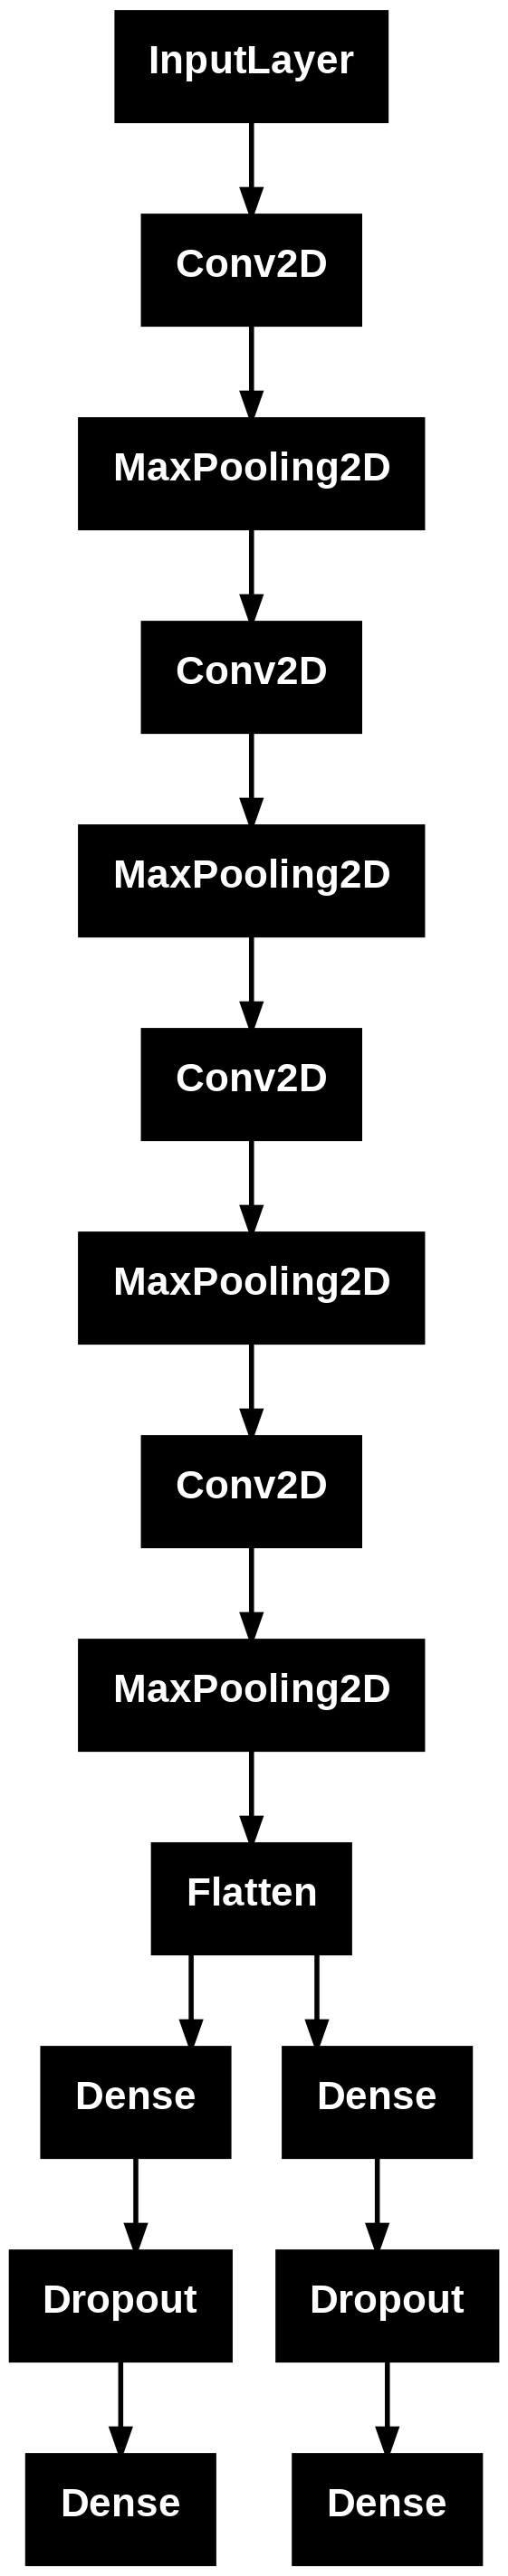

In [ ]:
# plot the model
from tensorflow.keras.utils import plot_model
plot_model(model)

In [ ]:
print(X.dtype, y_gender.dtype, y_age.dtype)


float32 object int64


In [ ]:
# Normalize images (Convert to float32 and scale to [0,1])
X = np.array(X, dtype=np.float32) / 255.0

# Convert labels to float32 and reshape them
y_gender = np.array([1 if label == "Female" else 0 for label in df['gender']], dtype=np.float32).reshape(-1, 1)
y_age = np.array(df['age'], dtype=np.float32).reshape(-1, 1)

# Check shapes and types
print("X shape:", X.shape, "dtype:", X.dtype)
print("y_gender shape:", y_gender.shape, "dtype:", y_gender.dtype)
print("y_age shape:", y_age.shape, "dtype:", y_age.dtype)


X shape: (740, 128, 128, 1) dtype: float32
y_gender shape: (740, 1) dtype: float32
y_age shape: (740, 1) dtype: float32


In [ ]:
history = model.fit(
    x=X,
    y={'gender_out': y_gender, 'age_out': y_age},  # Use dictionary format
    batch_size=32,
    epochs=5,
    validation_split=0.2,
    verbose=1
)


Epoch 1/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 229s 392ms/step - age_out_loss: 14.7502 - age_out_mae: 14.7395 - gender_out_accuracy: 0.5286 - gender_out_loss: 0.7032 - loss: 15.4428 - val_age_out_loss: 5.2921 - val_age_out_mae: 5.2774 - val_gender_out_accuracy: 0.4392 - val_gender_out_loss: 0.7201 - val_loss: 6.0069
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - age_out_loss: 9.2957 - age_out_mae: 9.3099 - gender_out_accuracy: 0.5234 - gender_out_loss: 0.7019 - loss: 10.0118 - val_age_out_loss: 4.2781 - val_age_out_mae: 4.2634 - val_gender_out_accuracy: 0.5608 - val_gender_out_loss: 0.6918 - val_loss: 4.9539
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - age_out_loss: 6.5355 - age_out_mae: 6.5345 - gender_out_accuracy: 0.5233 - gender_out_loss: 0.6878 - loss: 7.2223 - val_age_out_loss: 2.1184 - val_age_out_mae: 2.1037 - val_gender_out_accuracy: 0.4392 - val_gender_out_loss: 0.7072 - val_loss: 2.8170
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - age_out_loss: 6.6667 - age_out_mae:

## Plot the Results

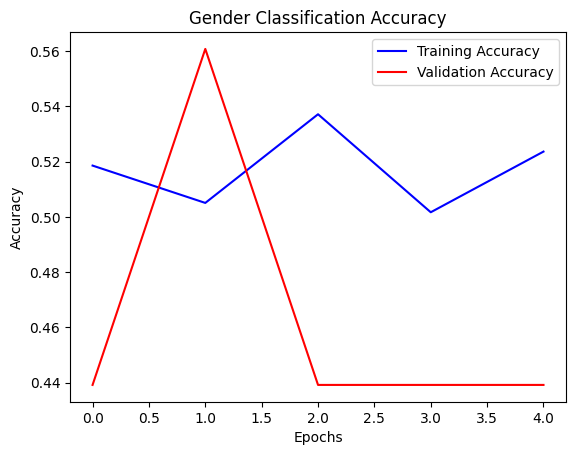

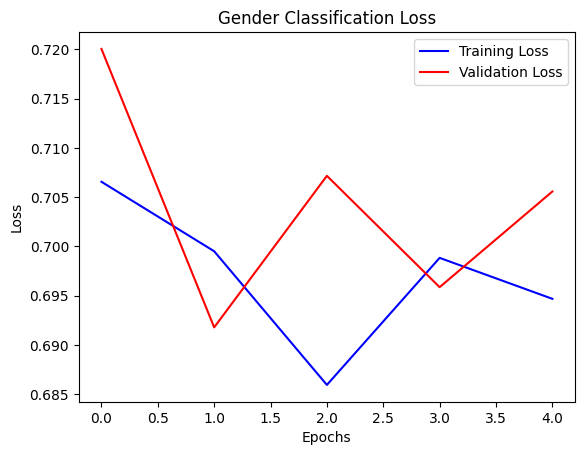

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracy values
acc = history.history.get('gender_out_accuracy', history.history.get('gender_out_acc'))
val_acc = history.history.get('val_gender_out_accuracy', history.history.get('val_gender_out_acc'))
epochs = range(len(acc))

# Plot Accuracy
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Gender Classification Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.figure()

# Extract loss values
loss = history.history['gender_out_loss']
val_loss = history.history['val_gender_out_loss']

# Plot Loss
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Gender Classification Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


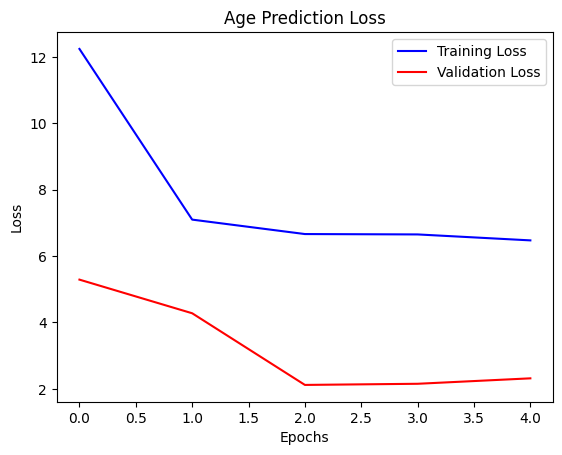

In [ ]:
import matplotlib.pyplot as plt

# Extract loss values
loss = history.history.get('age_out_loss')
val_loss = history.history.get('val_age_out_loss')
epochs = range(len(loss))

# Plot Loss for Age Prediction
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Age Prediction Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Prediction with Test Data

Original Gender: Male Original Age: 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted Gender: Female Predicted Age: 13


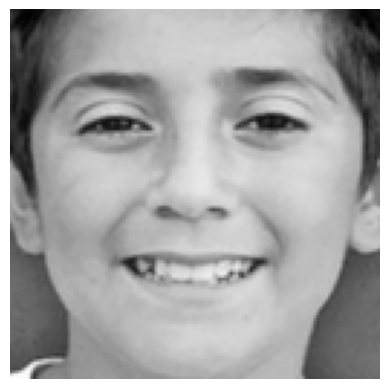

In [ ]:
import matplotlib.pyplot as plt

# Dictionary to map numerical labels to gender
gender_dict = {0: "Male", 1: "Female"}

# Select image index
image_index = 100

# Print original labels
original_gender = gender_dict[int(y_gender[image_index][0])]  # Convert to int before indexing
original_age = int(y_age[image_index][0])  # Convert age to integer

print("Original Gender:", original_gender, "Original Age:", original_age)

# Predict from model
pred = model.predict(X[image_index].reshape(1, 128, 128, 1))

# Ensure predictions are scalars before rounding
pred_gender = gender_dict[int(round(float(pred[0][0])))]  # Convert to float before rounding
pred_age = int(round(float(pred[1][0])))  # Convert to float before rounding

# Print predictions
print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)

# Display image
plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128), cmap='gray')
plt.show()


Original Gender: Female Original Age: 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted Gender: Female Predicted Age: 13


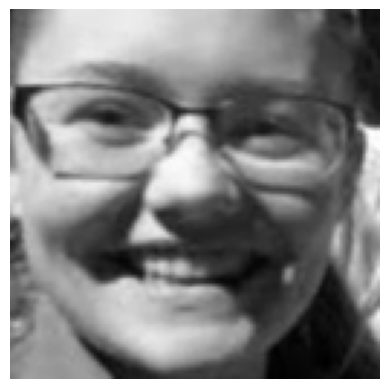

In [ ]:
import matplotlib.pyplot as plt

# Dictionary to map numerical labels to gender
gender_dict = {0: "Male", 1: "Female"}

# Select image index
image_index = 730  # Ensure this is within range (0 to 739)

# Check if image_index is within valid range
if image_index >= len(X):
    print(f"Error: image_index {image_index} is out of range. Max index is {len(X) - 1}.")
else:
    # Print original labels
    original_gender = gender_dict[int(y_gender[image_index][0])]  # Convert to int before indexing
    original_age = int(y_age[image_index][0])  # Convert age to integer

    print("Original Gender:", original_gender, "Original Age:", original_age)

    # Predict from model
    pred = model.predict(X[image_index].reshape(1, 128, 128, 1))

    # Ensure predictions are scalars before rounding
    pred_gender = gender_dict[int(round(float(pred[0][0])))]  # Convert to float before rounding
    pred_age = int(round(float(pred[1][0])))  # Convert to float before rounding

    # Print predictions
    print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)

    # Display image
    plt.axis('off')
    plt.imshow(X[image_index].reshape(128, 128), cmap='gray')
    plt.show()


Original Gender: Female Original Age: 14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Gender: Female Predicted Age: 13


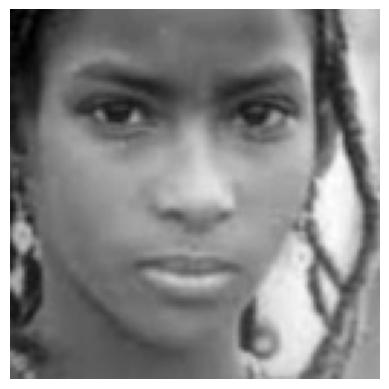

In [91]:
import matplotlib.pyplot as plt

# Dictionary to map numerical labels to gender
gender_dict = {0: "Male", 1: "Female"}

# Select image index
image_index = 568  # Adjusted to be within the dataset range

# Check if image_index is valid
if image_index >= len(X):
    print(f"Error: image_index {image_index} is out of range. Max index is {len(X) - 1}.")
else:
    # Print original labels
    original_gender = gender_dict[int(y_gender[image_index][0])]  # Convert to int before indexing
    original_age = int(y_age[image_index][0])  # Convert to integer

    print("Original Gender:", original_gender, "Original Age:", original_age)

    # Predict from model
    pred = model.predict(X[image_index].reshape(1, 128, 128, 1))

    # Ensure predictions are scalars before rounding
    pred_gender = gender_dict[int(round(float(pred[0][0])))]  # Convert to float before rounding
    pred_age = int(round(float(pred[1][0])))  # Convert to float before rounding

    # Print predictions
    print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)

    # Display image
    plt.axis('off')
    plt.imshow(X[image_index].reshape(128, 128), cmap='gray')
    plt.show()
